# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "densenet169-torch"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Experimental

In [3]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

device = torch.device("cuda:0")
model = models.densenet169().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = model.to(device)


### PyTorch (Baseline)

In [4]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
output = model(image)
grad = torch.randn_like(output)

df = pd.DataFrame()

baseline_f = torch_model_benchmark(model, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-native-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
#baseline_b = timeit("torch.autograd.grad(output_native, [image], grad, retain_graph=True)")
print('torch-native-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Native")])
print(df)

torch-native-gpu-forward:  [11.20965062800023, 11.110278140115845, 10.924578392626467, 10.817942041735927, 10.82477193359319, 10.822358750947961, 10.814716066191863, 10.831100597709149, 10.834449574955412, 10.817176343554312, 10.819761283897064]
10.89334397757522
torch-native-gpu-backward:  [8.286732148278404, 8.295791156522863, 8.843290569210374, 8.8909886492131, 8.89893518005674, 8.575452684617794, 8.843629327309024, 8.882505441638264, 8.761657712360224, 8.823821967182395, 8.879808213998068]
8.72569209548975
        time      pass          item
0  10.893344   Forward  Torch Native
0   8.725692  Backward  Torch Native
0  19.619036      Full  Torch Native


In [5]:

model_dynamo = torch.compile(model, backend="inductor")

image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)

output = model_dynamo(image)
grad = torch.randn_like(output)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [12.426261756535585, 12.403677645567301, 12.400806764023262, 12.375193001987698, 12.410269429286322, 12.402360361103003, 12.383475840964296, 12.397439428814897, 12.396213674062007, 12.363235399059885, 12.370706141532006]
12.393603585721479
torch-dynamo-gpu-backward:  [12.6368572163555, 12.50039390078536, 12.517013024907929, 12.516676347602058, 12.516021938272962, 12.542415670379324, 12.532974022801396, 12.541854158379472, 12.53326593789163, 12.534397394136267, 12.25172000022622]
12.51123541924892
        time      pass          item
0  10.893344   Forward  Torch Native
0   8.725692  Backward  Torch Native
0  19.619036      Full  Torch Native
0  12.393604   Forward  Torch Dynamo
0  12.511235  Backward  Torch Dynamo
0  24.904839      Full  Torch Dynamo


In [6]:
df.style.hide(axis="index")

time,pass,item
10.893344,Forward,Torch Native
8.725692,Backward,Torch Native
19.619036,Full,Torch Native
12.393604,Forward,Torch Dynamo
12.511235,Backward,Torch Dynamo
24.904839,Full,Torch Dynamo


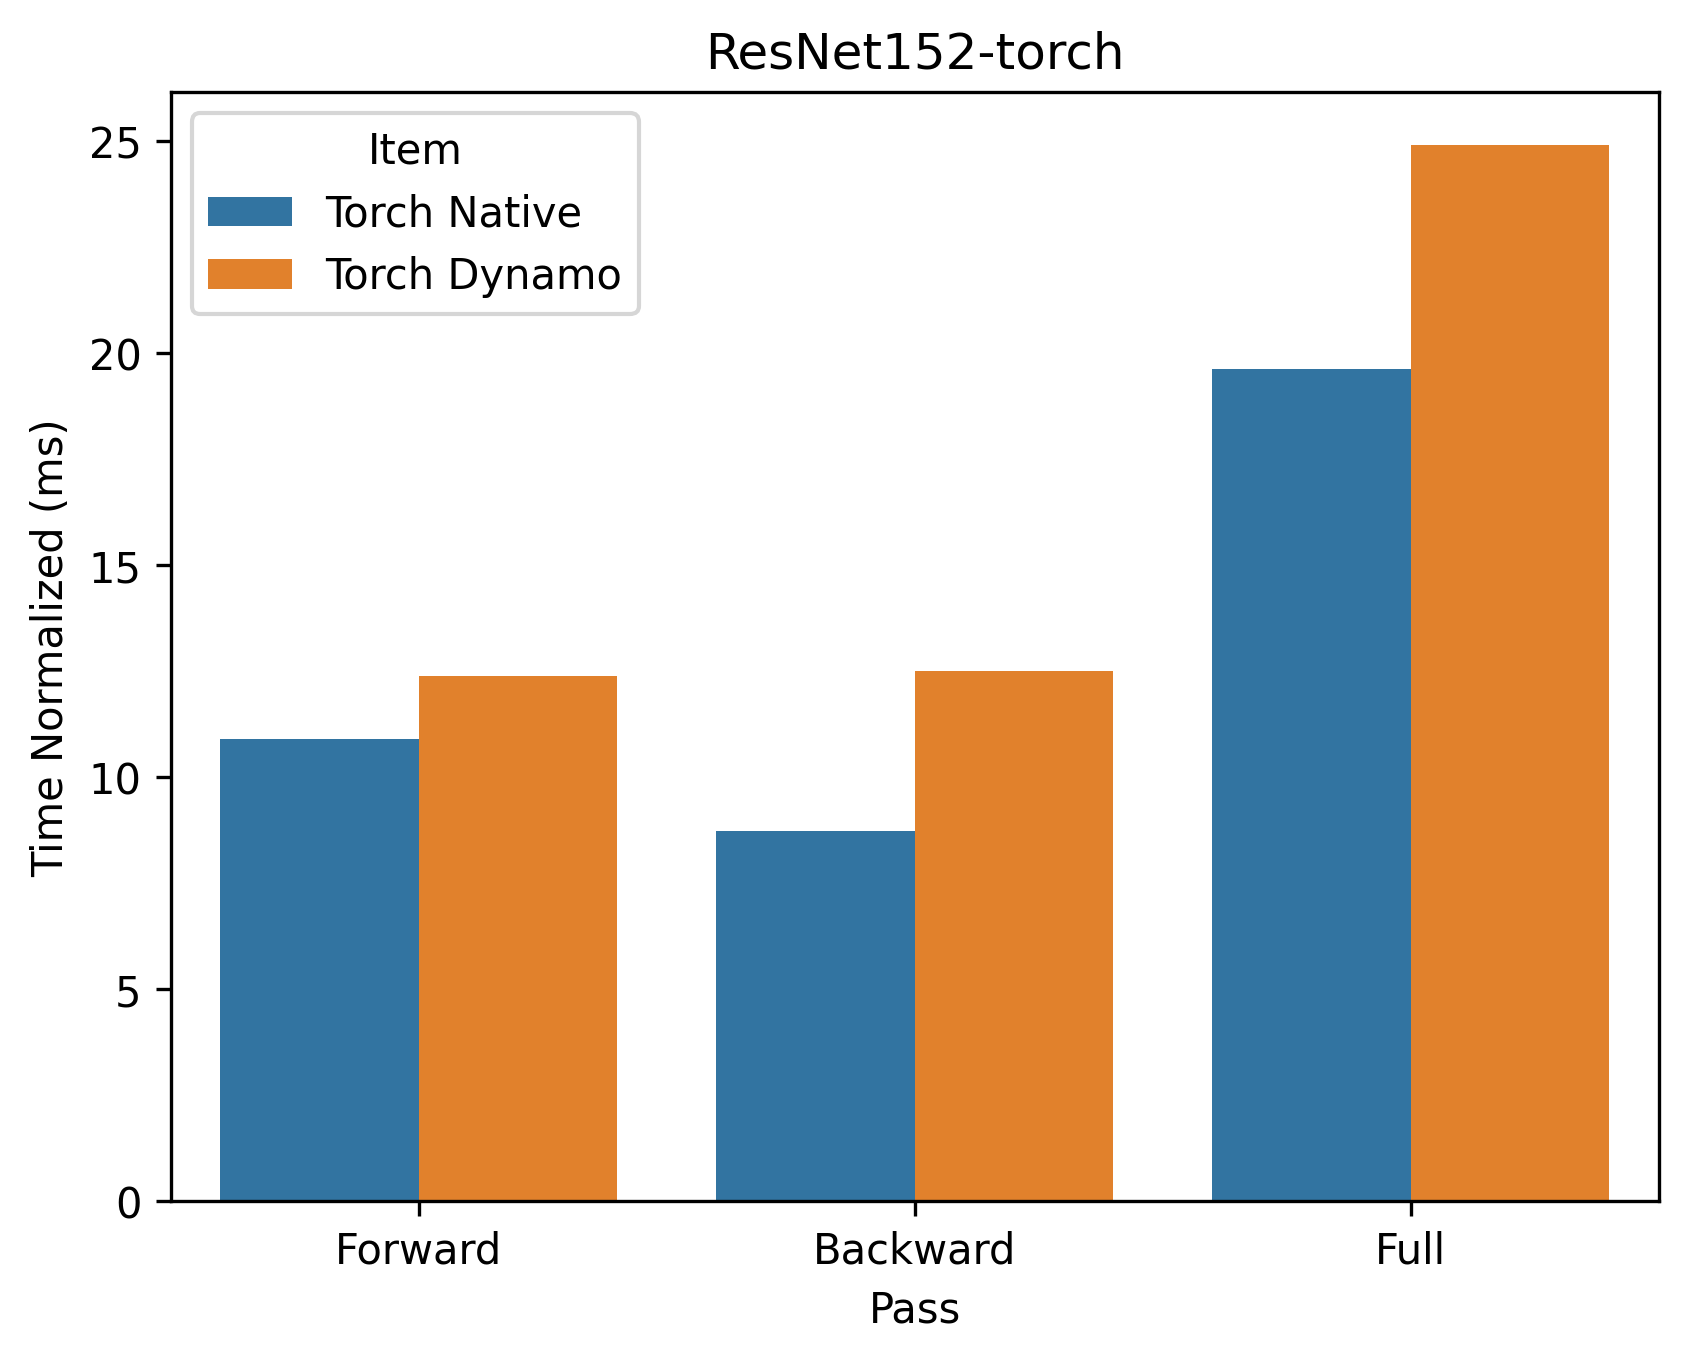

In [7]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [8]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,10.893344,Forward,Torch Native,1.137723
0,12.393604,Forward,Torch Dynamo,1.000000


In [9]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,8.725692,Backward,Torch Native,1.433839
0,12.511235,Backward,Torch Dynamo,1.000000


In [10]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,19.619036,Full,Torch Native,1.269422
0,24.904839,Full,Torch Dynamo,1.000000


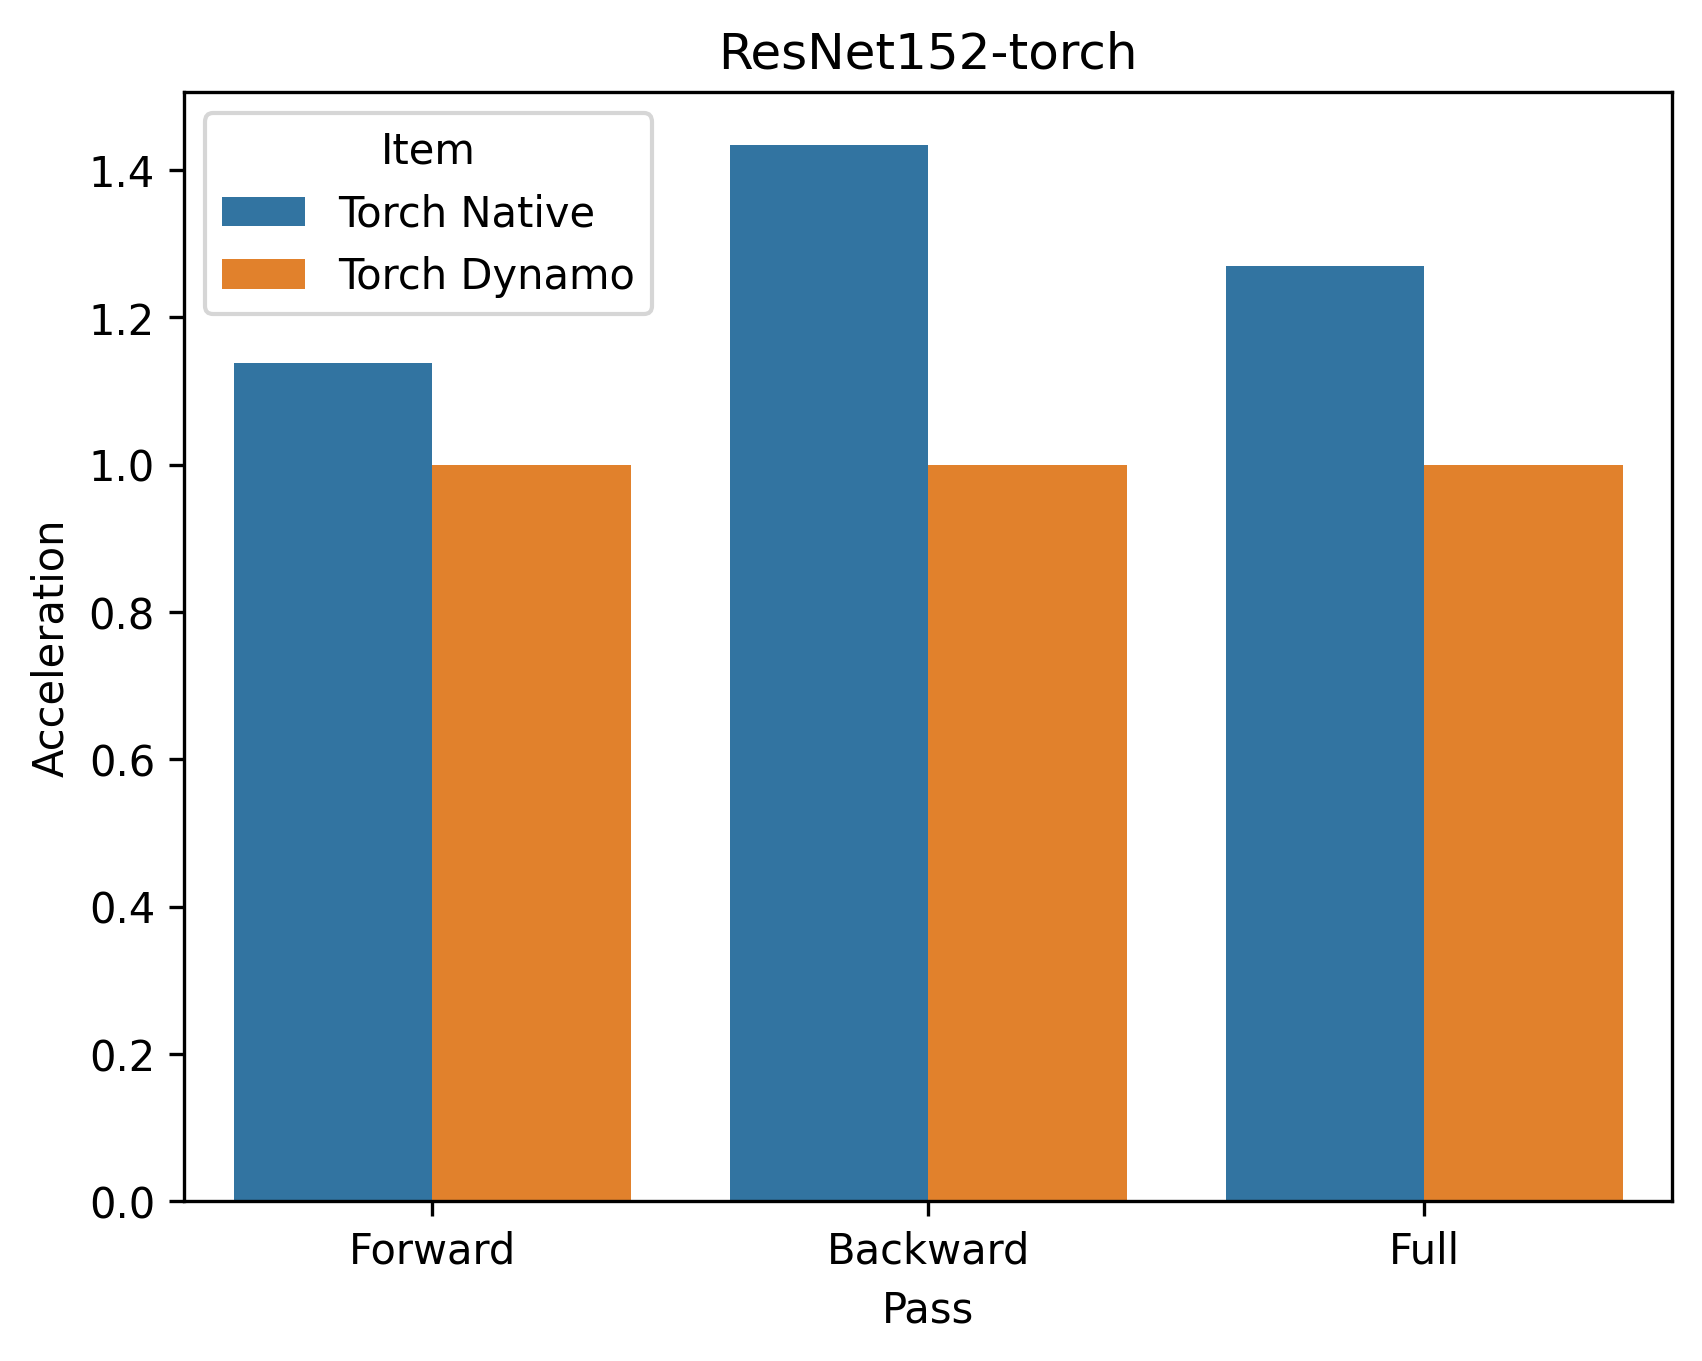

In [11]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")